# Análisis Exploratorio de Datos (EDA)

Pasos:
1. Importar librerías y preparar el environment.
2. Conectar a MySQL y exportar las tablas a ficheros (`datos/tablas.pkl`).
3. Mostrar las tablas disponibles.
4. Cargar tablas en DataFrames.
5. Realizar un análisis exploratorio con estadísticas y tablas de correlación.
6. Generar reportes de análisis exploratorio en HTML usando la librería Sweetviz.

IMPORTANTE:
1. Cada vez que se ejecuta el **paso 2**, se sobreescriben las tablas con la información de la BD.
2. **Si el fichero con las tablas ya ha sido generado** no es necesario ejecutar los primeros 3 pasos. **Puede ir directamente al paso 4**.



### Requisitos previos


In [2]:
# %pip install -q sweetviz sqlalchemy mysql-connector-python pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: C:\Users\cesar\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


## 1. Importación de librerías

In [1]:
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sweetviz as sv

sns.set_theme(style="whitegrid")

---
## 2. Conexión a la base de datos y exportación de ficheros

1. Creamos la conexión a MySQL.
2. Descargamos las tablas de la BD.
3. Guardamos los datos en `datos/tablas.pkl` para reutilizarlos sin volver a consultar la BD.

IMPORTANTE: Cada vez que se ejecuta este paso se sobreescriben las tablas con la información de la BD.

In [ ]:
from DB import RUTA_DATOS, refrescar_datos

datos = refrescar_datos()

print(f"Fichero listo para usar: {RUTA_DATOS}")
for nombre, df in datos.items():
    print(f"  - {nombre}: {df.shape[0]} filas x {df.shape[1]} columnas")

8 tablas exportadas a: c:\Users\cesar\OneDrive\Documentos\Master\Proyecto Jupiter\EDA y limpieza de errores\datos\tablas.pkl
Fichero listo para usar: c:\Users\cesar\OneDrive\Documentos\Master\Proyecto Jupiter\EDA y limpieza de errores\datos\tablas.pkl
  - cliente: 34 filas x 2 columnas
  - lote: 69567 filas x 2 columnas
  - marca: 35 filas x 2 columnas
  - producto: 70549 filas x 9 columnas
  - proveedor: 35 filas x 2 columnas
  - subtipo: 27 filas x 3 columnas
  - tipo: 15 filas x 2 columnas
  - venta: 70549 filas x 6 columnas


---
## 3. Listar las tablas disponibles


In [5]:
from DB import obtener_tablas

tablas = obtener_tablas()
print(f"Tablas en {RUTA_DATOS} ({len(tablas)}):")
for tabla in tablas:
    print(f"  - {tabla}")

Tablas en c:\Users\cesar\OneDrive\Documentos\Master\Proyecto Jupiter\EDA y limpieza de errores\datos\tablas.pkl (8):
  - cliente
  - lote
  - marca
  - producto
  - proveedor
  - subtipo
  - tipo
  - venta


## 4. Cargar tablas en DataFrames

In [1]:
from DB import cargar_datos
# Cargamos las tablas en DataFrames
datos = cargar_datos("datos/tablas.pkl")

print(f"Tablas cargadas desde fichero: {len(datos)}")
for nombre, df in datos.items():
    print(f"  - {nombre}: {df.shape[0]} filas x {df.shape[1]} columnas")

Tablas cargadas desde fichero: 8
  - cliente: 34 filas x 2 columnas
  - lote: 69567 filas x 2 columnas
  - marca: 35 filas x 2 columnas
  - producto: 70549 filas x 9 columnas
  - proveedor: 35 filas x 2 columnas
  - subtipo: 27 filas x 3 columnas
  - tipo: 15 filas x 2 columnas
  - venta: 70549 filas x 6 columnas


### 4.1 Vista rápida de cada tabla

1. **Primeras filas** (`head()`): estructura y valores de ejemplo.
2. **Información general** (`info()`): tipos de datos y valores nulos.
3. **Estadísticas descriptivas** (`describe()`): medidas numéricas básicas.

In [2]:
# 1. Primeras filas

for nombre, df in datos.items():
    print(f"\n\n### {nombre} ###\n")
    display(df.head())



### cliente ###



,id_cliente,nombre
0,1,Alimentación Total
1,2,Alimentos Premium
2,3,Almacén Estrella
3,4,Central de Abastos Central
4,5,Comercial Fresco




### lote ###



,id_lote,codigo
0,1,B69J65V80R69K49I67U80I46V78M
1,2,B69J65V80R69K49J80T71
2,3,B69J65V80R69K49L45I79V89J80T71
3,4,B69J65V80R69K49L46V78M
4,5,B69J65V80R69K49M45I79V89J80T71




### marca ###



...

,id_subtipo,nombre,id_tipo
0,1,Apple A,1
1,2,Apple B,1
2,3,Apple C,1
3,4,Apple D,1
4,5,Apple E,1




### tipo ###



,id_tipo,nombre
0,1,Apple
1,2,Banana
2,3,Carambola
3,4,Guava
4,5,Kiwi




### venta ###



,id_venta,id_producto,id_cliente,precio_venta,tiempo_venta,peso
0,1,1,6,4.91,2025-09-19 12:00:00,264.20
1,2,2,6,3.43,2025-09-12 02:00:00,141.65
2,3,3,20,3.18,2025-09-19 22:00:00,151.92
3,4,4,32,4.13,2025-09-28 17:00:00,442.48
4,5,5,33,3.35,2025-09-19 03:00:00,423.78


In [ ]:
# 2. Información general

for nombre, df in datos.items():
    print(f"\n\n### {nombre} ###\n")
    df.info()
    print()



### cliente ###

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_cliente  34 non-null     int64 
 1   nombre      34 non-null     object
dtypes: int64(1), object(1)
memory usage: 676.0+ bytes



### lote ###

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69567 entries, 0 to 69566
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id_lote  69567 non-null  int64 
 1   codigo   69567 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.1+ MB



### marca ###

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id_marca  35 non-null     int64 
 1   nombre    35 non-null     object
dtypes: int64(1), object(1)
memory usage: 692.0+ bytes



### product

In [12]:
# 3. Estadísticas descriptivas

for nombre, df in datos.items():
    print(f"\n\n### {nombre} ###\n")
    display(df.describe(include="all").T)
    print()



### cliente ###



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_cliente,34.0,NaN,NaN,NaN,17.5,9.958246,1.0,9.25,17.5,25.75,34.0
nombre,34,34,Alimentación Total,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN





### lote ###



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_lote,69567.0,NaN,NaN,NaN,34784.0,20082.407425,1.0,17392.5,34784.0,52175.5,69567.0
codigo,69567,69567,B69J65V80R69K49I67U80I46V78M,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN





### marca ###



...

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_subtipo,27.0,NaN,NaN,NaN,14.0,7.937254,1.0,7.5,14.0,20.5,27.0
nombre,27,27,Apple A,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id_tipo,27.0,NaN,NaN,NaN,5.666667,4.394052,1.0,1.5,5.0,8.5,15.0





### tipo ###



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_tipo,15.0,NaN,NaN,NaN,8.0,4.472136,1.0,4.5,8.0,11.5,15.0
nombre,15,15,Apple,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN





### venta ###



,count,mean,min,25%,50%,75%,max,std
id_venta,70549.0,35275.0,1.0,17638.0,35275.0,52912.0,70549.0,20365.886408
id_producto,70549.0,35275.0,1.0,17638.0,35275.0,52912.0,70549.0,20365.886408
id_cliente,70549.0,17.569448,1.0,9.0,18.0,26.0,34.0,9.796134
precio_venta,69855.0,3.498903,0.32,3.02,3.5,3.97,6.85,0.706285
tiempo_venta,70326,2025-09-16 11:25:45.482467584,2025-08-31 15:00:00,2025-09-09 00:00:00,2025-09-16 11:00:00,2025-09-24 00:00:00,2025-10-01 20:00:00,NaN
peso,70549.0,300.241984,-101.6,232.66,300.2,367.95,706.15,99.976572


---
## 5. Análisis exploratorio y correlaciones

- Conteo de **valores nulos** por columna.
- **Matriz de correlación** entre columnas numéricas (valores entre -1 y 1).
- **Mapa de calor** (*heatmap*) para visualizar las correlaciones.



### cliente ###


--- Valores nulos ---
  No hay valores nulos.

  Se necesitan al menos 2 columnas numéricas para calcular correlaciones.


### lote ###


--- Valores nulos ---
  No hay valores nulos.

  Se necesitan al menos 2 columnas numéricas para calcular correlaciones.


### marca ###


--- Valores nulos ---
  No hay valores nulos.

  Se necesitan al menos 2 columnas numéricas para calcular correlaciones.


### producto ###


--- Valores nulos ---


,conteo_nulos
coste_inicial,2011



--- Tabla de correlación ---


,id_producto,id_tipo,id_subtipo,id_marca,id_proveedor,id_lote,coste_inicial
id_producto,1.000,0.902,0.958,-0.001,0.001,0.795,0.001
id_tipo,0.902,1.000,0.956,-0.001,0.001,0.666,-0.002
id_subtipo,0.958,0.956,1.000,-0.001,0.003,0.754,-0.001
id_marca,-0.001,-0.001,-0.001,1.000,0.001,0.001,-0.002
id_proveedor,0.001,0.001,0.003,0.001,1.000,0.000,0.005
id_lote,0.795,0.666,0.754,0.001,0.000,1.000,0.001
coste_inicial,0.001,-0.002,-0.001,-0.002,0.005,0.001,1.000


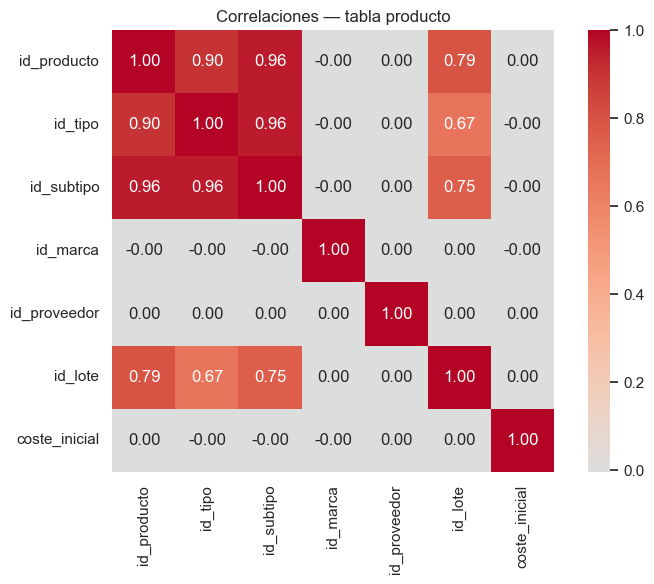



### proveedor ###


--- Valores nulos ---
  No hay valores nulos.

  Se necesitan al menos 2 columnas numéricas para calcular correlaciones.


### subtipo ###


--- Valores nulos ---
  No hay valores nulos.

--- Tabla de correlación ---


,id_subtipo,id_tipo
id_subtipo,1.000,0.957
id_tipo,0.957,1.000


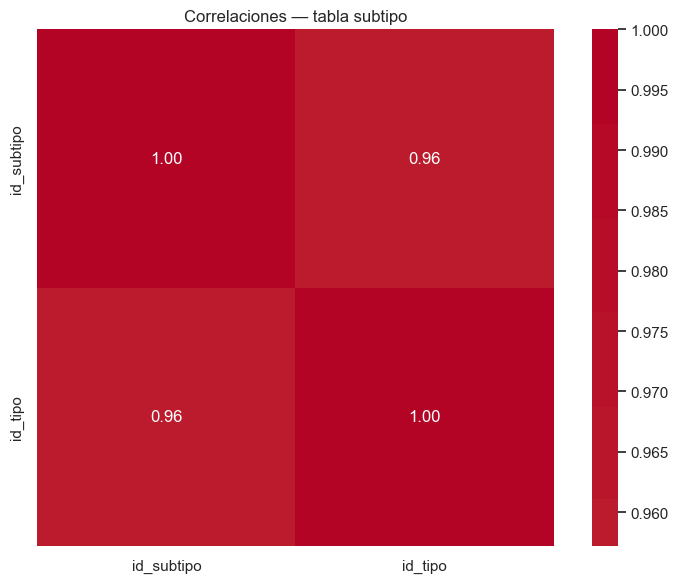



### tipo ###


--- Valores nulos ---
  No hay valores nulos.

  Se necesitan al menos 2 columnas numéricas para calcular correlaciones.


### venta ###


--- Valores nulos ---


,conteo_nulos
precio_venta,694
tiempo_venta,223



--- Tabla de correlación ---


,id_venta,id_producto,id_cliente,precio_venta,peso
id_venta,1.000,1.000,-0.000,0.005,-0.002
id_producto,1.000,1.000,-0.000,0.005,-0.002
id_cliente,-0.000,-0.000,1.000,-0.003,-0.001
precio_venta,0.005,0.005,-0.003,1.000,0.006
peso,-0.002,-0.002,-0.001,0.006,1.000


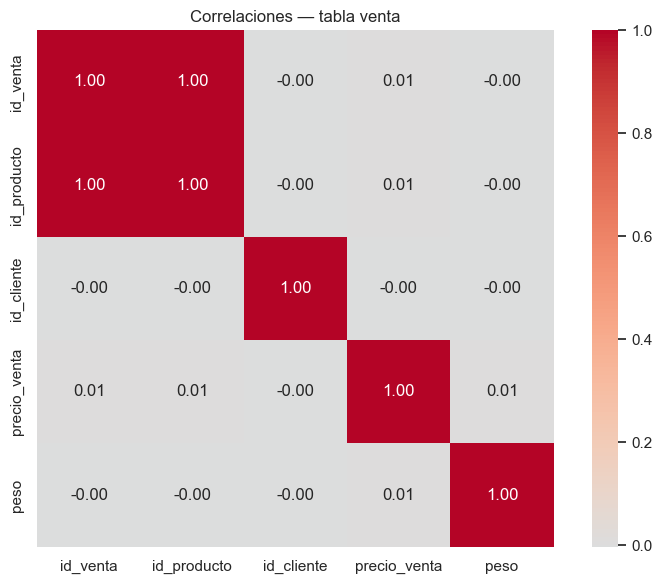

In [15]:
def analizar_tabla(nombre, df):
    print(f"\n\n### {nombre} ###\n")

    # Valores nulos
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0]
    print("\n--- Valores nulos ---")
    if nulos.empty:
        print("  No hay valores nulos.")
    else:
        display(nulos.to_frame("conteo_nulos"))

    # Columnas numéricas
    df_num = df.select_dtypes(include="number")

    if df_num.shape[1] < 2:
        print("\n  Se necesitan al menos 2 columnas numéricas para calcular correlaciones.")
        return

    # Matriz de correlación y heatmap
    correlacion = df_num.corr(numeric_only=True)
    print("\n--- Tabla de correlación ---")
    display(correlacion.round(3))

    plt.figure(figsize=(8, 6))
    sns.heatmap(correlacion, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
    plt.title(f"Correlaciones — tabla {nombre}")
    plt.tight_layout()
    plt.show()

for nombre, df in datos.items():
    analizar_tabla(nombre, df)

---
## 6. Análisis Exploratorio de Datos (EDA) con Sweetviz


In [16]:

# Generamos la tabla con los EDA usando Sweetviz
def generar_eda_html(tabla, carpeta="reportes_html"):
    df = datos[tabla]

    os.makedirs(carpeta, exist_ok=True)

    reporte = sv.analyze(df)

    ruta = os.path.join(carpeta, f"EDA_{tabla}.html")
    reporte.show_html(ruta)

    print(f"Reporte HTML generado: {ruta}")
    return ruta

In [17]:
# Imprimimos generamos los EDA en formato HTML
for tabla in tablas:
    generar_eda_html(tabla)



                                             |          | [  0%]   00:00 -> (? left)

Report reportes_html\EDA_cliente.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
Reporte HTML generado: reportes_html\EDA_cliente.html


                                             |          | [  0%]   00:00 -> (? left)

Report reportes_html\EDA_lote.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
Reporte HTML generado: reportes_html\EDA_lote.html


                                             |          | [  0%]   00:00 -> (? left)

...

Report reportes_html\EDA_subtipo.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
Reporte HTML generado: reportes_html\EDA_subtipo.html


                                             |          | [  0%]   00:00 -> (? left)

Report reportes_html\EDA_tipo.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
Reporte HTML generado: reportes_html\EDA_tipo.html


                                             |          | [  0%]   00:00 -> (? left)

Report reportes_html\EDA_venta.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
Reporte HTML generado: reportes_html\EDA_venta.html
